# [3.0] DESI x LSST DP1 object and dia_object

In this notebook, we will:
- **crossmatch** two pairs of catalogs:
  - DESI Main Survey (dark program) DR1 with LSST DP1 **object** catalog
  - DESI Main Survey (dark program) DR1 with LSST DP1 **dia_object** catalog
- **save** the resulting catalogs to the NERSC Community File System (CFS)
- discuss **performance and resource use** of the crossmatch

## Set up

In [2]:
import os
import time
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog

In [3]:
# Check on our output directory

users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"

! tree -L 1 $target_user_dir

/global/cfs/cdirs/cosmo/users/olynn
├── collection.properties
├── desi-dr1-coadd-test
├── desi-dr1-main-dark
└── desi_x_gaia

3 directories, 1 file


In [4]:
# Make a dask client

client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)

In [5]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004149:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


## Load catalogs

In [6]:
desi_cat = lsdb.open_catalog("/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


In [ ]:
dp1_obj_cat = lsdb.open_catalog(
    "/global/cfs/cdirs/lsst/shared/rubin/DP1/HATS/dp1_full/hats/v29_0_0/object_collection",
    # columns=["objectId", "coord_ra", "coord_dec"]  # Neven says we can use all columns
)
dp1_obj_cat

,coord_dec,coord_decErr,coord_ra,coord_raErr,g_psfFlux,g_psfFluxErr,g_psfMag,g_psfMagErr,i_psfFlux,i_psfFluxErr,i_psfMag,i_psfMagErr,objectId,patch,r_psfFlux,r_psfFluxErr,r_psfMag,r_psfMagErr,refBand,refFwhm,shape_flag,shape_xx,shape_xy,shape_yy,tract,u_psfFlux,u_psfFluxErr,u_psfMag,u_psfMagErr,x,xErr,y,y_psfFlux,y_psfFluxErr,y_psfMag,y_psfMagErr,yErr,z_psfFlux,z_psfFluxErr,z_psfMag,z_psfMagErr,objectForcedSource
npartitions=389,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 130",double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],float[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], coord_dec: [double], co..."
"Order: 8, Pixel: 2176",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 9, Pixel: 2302101",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
dp1_dia_obj_cat = lsdb.open_catalog(
    "/global/cfs/cdirs/lsst/shared/rubin/DP1/HATS/dp1_full/hats/v29_0_0/dia_object_collection",
    # columns=["diaObjectId", "ra", "dec"]  # Neven says we can use all columns
)
dp1_dia_obj_cat

,diaObjectId,ra,dec
npartitions=208,,,
"Order: 6, Pixel: 130",int64[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 136",...,...,...
...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...
"Order: 7, Pixel: 143884",...,...,...


## Crossmatch 1: DESI x LSST DP1 object

In [16]:
desi_x_dp1_obj = desi_cat.crossmatch(dp1_obj_cat, suffix_method="overlapping_columns", suffixes=("_desi", "_dp1"))

In [17]:
start = time.perf_counter()

catalog_name_obj = "desi_x_lsst_dp1_object"
with performance_report(filename="crossmatch_report_obj.html"):
    desi_x_dp1_obj.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name_obj,
    )

elapsed_obj = time.perf_counter() - start

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])


In [18]:
print(f"Crossmatch took {int(elapsed_obj/60):d}m {elapsed_obj%60:.1f}s")

Crossmatch took 2m 3.0s


## Crossmatch 2: DESI x LSST DP1 dia_object

In [31]:
desi_x_dp1_dia_obj = desi_cat.crossmatch(dp1_dia_obj_cat, suffix_method="overlapping_columns", suffixes=("_desi", "_dp1"))

In [32]:
start = time.perf_counter()

catalog_name_dia_obj = "desi_x_lsst_dp1_dia_object"
with performance_report(filename="crossmatch_report_dia_obj.html"):
    desi_x_dp1_dia_obj.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name_dia_obj,
    )

elapsed_dia_obj = time.perf_counter() - start

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/lsdb/dask/merge_catalog_functions.py:232: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  joined_df = pd.concat([partition, margin])


In [33]:
print(f"Crossmatch took {int(elapsed_dia_obj/60):d}m {elapsed_dia_obj%60:.1f}s")

Crossmatch took 0m 41.0s


## Verify crossmatch 1: DESI x LSST DP1 object

In [19]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / catalog_name_obj

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi_x_lsst_dp1_object ... 
Found 60 partitions.
Approximate coverage is 0.01 % of the sky.


True

In [20]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

534M	/global/cfs/cdirs/cosmo/users/olynn/desi_x_lsst_dp1_object


In [40]:
# Open catalog

desi_x_dp1_obj_cat = lsdb.open_catalog(output_catalog)
desi_x_dp1_obj_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,diaObjectId,ra,dec,_dist_arcsec
npartitions=7,,,,,,,,,,,,
"Order: 6, Pixel: 130",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17885",...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17887",...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_lsst_dp1_dia_object'}>)

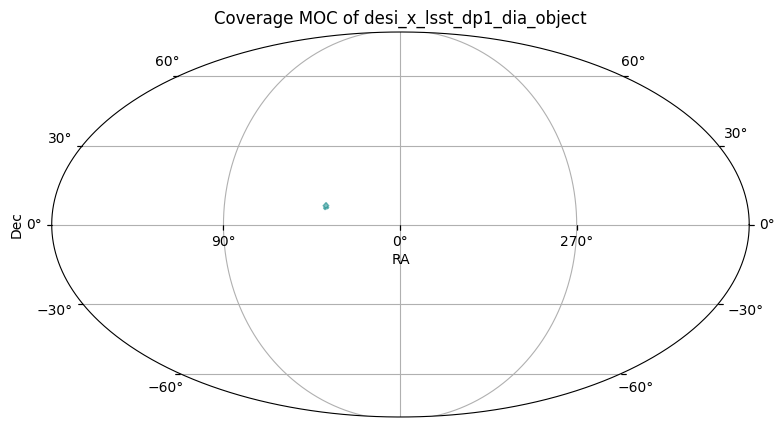

In [41]:
# Plot coverage

desi_x_dp1_obj_cat.plot_coverage()

In [43]:
# See the first few rows

df_obj = desi_x_dp1_obj_cat.head(5)
df_obj

TARGETID  TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                            
9194470120764197  39627930157977720  38.119619    5.969811  -0.00001   
9196142493359154  39627930162168188  38.177732    6.097595 -0.000078   
9199553915837907  39627936176800023  38.226914    6.173436  0.000081   
9200119795837772  39627936176802982   38.38235    6.224431   0.37122   
9200706905848582  39627936176801646  38.311705    6.268253  2.641446   

                      ZERR                                          spectra_b  \
_healpix_29                                                                     
9194470120764197  0.000083  [{wavelength: 3600.0, flux: 14.706099, ivar: 0...   
9196142493359154  0.000004  [{wavelength: 3600.0, flux: 16.388857, ivar: 0...   
9199553915837907  0.000005  [{wavelength: 3600.0, flux: 22.590179, ivar: 0...   
9200119795837772  0.000076  [{wavelength: 3600.0, flux: 1.826679, ivar: 0....   
9200706905848582  0.000355  [{wavelength: 3600.0, flux: 6.852676, ivar: 0....   

                                                          spectra_r  \
_healpix_29                                                           
9194470120764197  [{wavelength: 5760.0, flux: 2.254704, ivar: 2....   
9196142493359154  [{wavelength: 5760.0, flux: 21.66119, ivar: 0....   
9199553915837907  [{wavelength: 5760.0, flux: 26.044647, ivar: 0...   
9200119795837772  [{wavelength: 5760.0, flux: 0.591849, ivar: 3....   
9200706905848582  [{wavelength: 5760.0, flux: 8.769548, ivar: 0....   

                                                          spectra_z  \
_healpix_29                                                           
9194470120764197  [{wavelength: 7520.0, flux: 1.311252, ivar: 5....   
9196142493359154  [{wavelength: 7520.0, flux: 15.090705, ivar: 1...   
9199553915837907  [{wavelength: 7520.0, flux: 16.688299, ivar: 1...   
9200119795837772  [{wavelength: 7520.0, flux: 2.9867, ivar: 4.96...   
9200706905848582  [{wavelength: 7520.0, flux: 3.049568, ivar: 1....   

                         diaObjectId         ra       dec  _dist_arcsec  
_healpix_29                                                              
9194470120764197  648369431235264515   38.11965   5.96977      0.183285  
9196142493359154  648370049710555147  38.177748  6.097579       0.08257  
9199553915837907  648370049710555145  38.226932  6.173412      0.108008  
9200119795837772  648370668185845877  38.382193  6.224411      0.564966  
9200706905848582  648370736905322514  38.311735  6.268269      0.120212

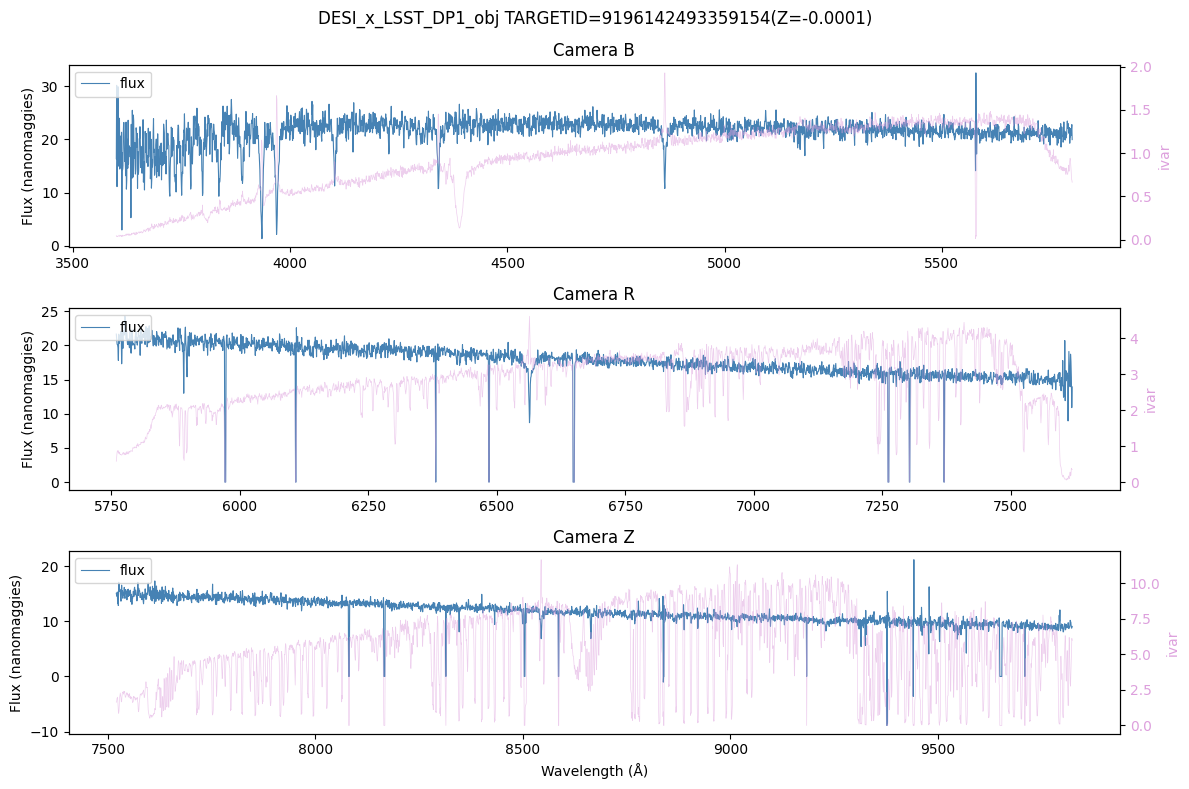

In [44]:
# Plot spectra of a row

target_idx = 1

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df_obj[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"DESI_x_LSST_DP1_obj TARGETID={df_obj.index[target_idx]}(Z={df_obj['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Verify crossmatch 2: DESI x LSST DP1 dia_object

In [34]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / catalog_name_dia_obj

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi_x_lsst_dp1_dia_object ... 
Found 7 partitions.
Approximate coverage is 0.01 % of the sky.


True

In [35]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

/global/common/software/nersc/pe/conda-envs/26.1.0/python-3.12/nersc-python/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=1626711) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


27M	/global/cfs/cdirs/cosmo/users/olynn/desi_x_lsst_dp1_dia_object


In [45]:
# Open catalog

desi_x_dp1_dia_obj_cat = lsdb.open_catalog(output_catalog)
desi_x_dp1_dia_obj_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z,diaObjectId,ra,dec,_dist_arcsec
npartitions=7,,,,,,,,,,,,
"Order: 6, Pixel: 130",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17885",...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 17887",...,...,...,...,...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi_x_lsst_dp1_dia_object'}>)

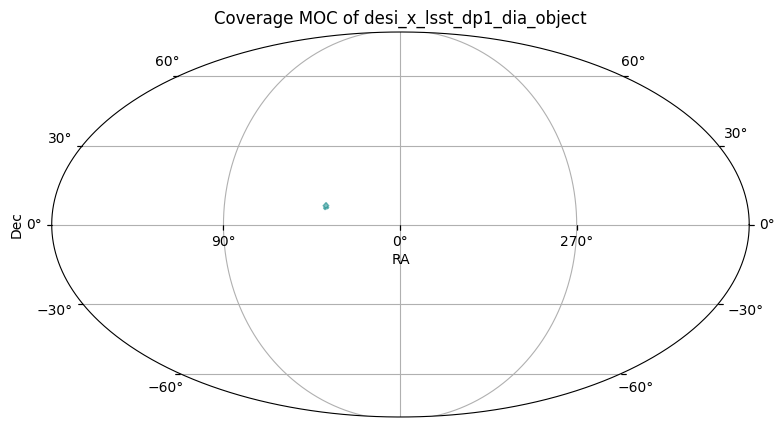

In [46]:
# Plot coverage

desi_x_dp1_dia_obj_cat.plot_coverage()

In [ ]:
# See the first few rows

df_dia_obj = desi_x_dp1_dia_obj_cat.head(5)
df_dia_obj

TARGETID  TARGET_RA  TARGET_DEC         Z  \
_healpix_29                                                            
9194470120764197  39627930157977720  38.119619    5.969811  -0.00001   
9196142493359154  39627930162168188  38.177732    6.097595 -0.000078   
9199553915837907  39627936176800023  38.226914    6.173436  0.000081   
9200119795837772  39627936176802982   38.38235    6.224431   0.37122   
9200706905848582  39627936176801646  38.311705    6.268253  2.641446   

                      ZERR                                          spectra_b  \
_healpix_29                                                                     
9194470120764197  0.000083  [{wavelength: 3600.0, flux: 14.706099, ivar: 0...   
9196142493359154  0.000004  [{wavelength: 3600.0, flux: 16.388857, ivar: 0...   
9199553915837907  0.000005  [{wavelength: 3600.0, flux: 22.590179, ivar: 0...   
9200119795837772  0.000076  [{wavelength: 3600.0, flux: 1.826679, ivar: 0....   
9200706905848582  0.000355  [{wavelength: 3600.0, flux: 6.852676, ivar: 0....   

                                                          spectra_r  \
_healpix_29                                                           
9194470120764197  [{wavelength: 5760.0, flux: 2.254704, ivar: 2....   
9196142493359154  [{wavelength: 5760.0, flux: 21.66119, ivar: 0....   
9199553915837907  [{wavelength: 5760.0, flux: 26.044647, ivar: 0...   
9200119795837772  [{wavelength: 5760.0, flux: 0.591849, ivar: 3....   
9200706905848582  [{wavelength: 5760.0, flux: 8.769548, ivar: 0....   

                                                          spectra_z  \
_healpix_29                                                           
9194470120764197  [{wavelength: 7520.0, flux: 1.311252, ivar: 5....   
9196142493359154  [{wavelength: 7520.0, flux: 15.090705, ivar: 1...   
9199553915837907  [{wavelength: 7520.0, flux: 16.688299, ivar: 1...   
9200119795837772  [{wavelength: 7520.0, flux: 2.9867, ivar: 4.96...   
9200706905848582  [{wavelength: 7520.0, flux: 3.049568, ivar: 1....   

                         diaObjectId         ra       dec  _dist_arcsec  
_healpix_29                                                              
9194470120764197  648369431235264515   38.11965   5.96977      0.183285  
9196142493359154  648370049710555147  38.177748  6.097579       0.08257  
9199553915837907  648370049710555145  38.226932  6.173412      0.108008  
9200119795837772  648370668185845877  38.382193  6.224411      0.564966  
9200706905848582  648370736905322514  38.311735  6.268269      0.120212

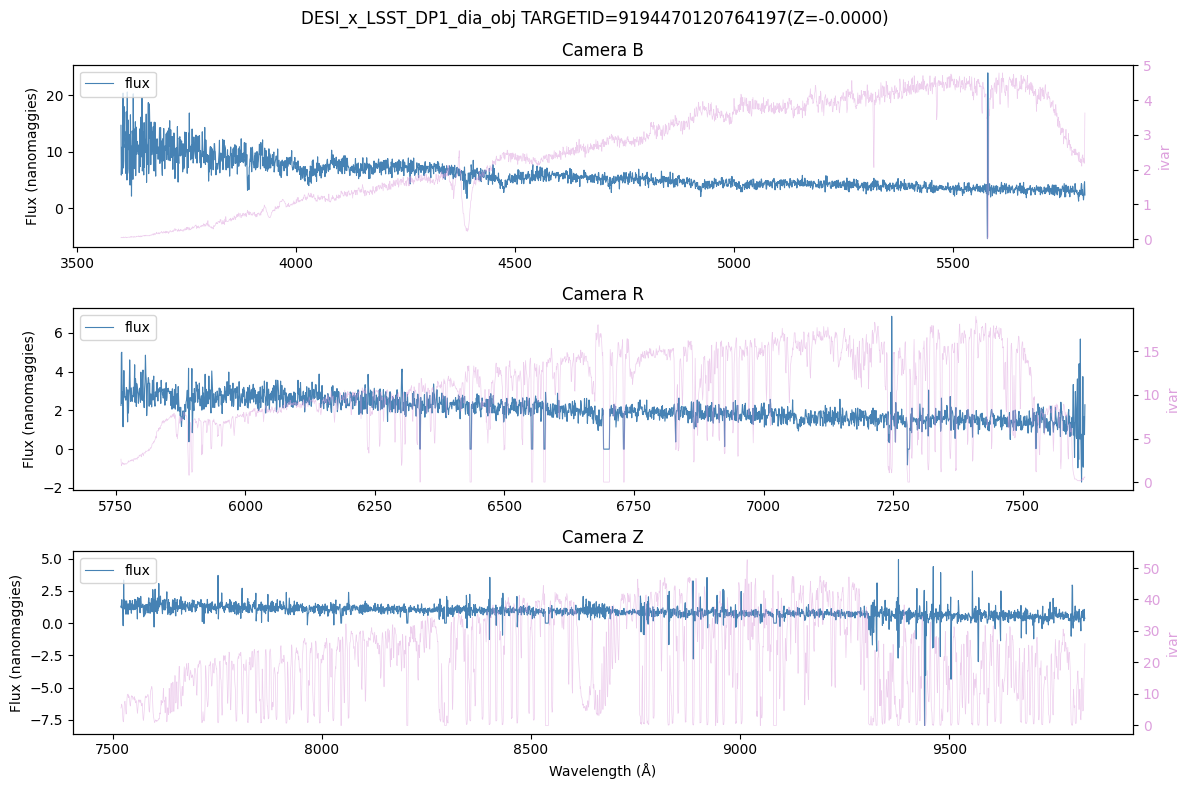

In [ ]:
# Plot spectra of a row

target_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df_dia_obj[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"DESI_x_LSST_DP1_dia_obj TARGETID={df_dia_obj.index[target_idx]}(Z={df_dia_obj['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Performance Analysis

In [13]:
# Generate markdown tables for the Dask dashboard reports

from dask_report_utils import client_table, metrics_table

print(client_table("crossmatch_report_obj.html", threads_per_worker=2, memory_limit_per_worker="14 GB"), "\n")
print(metrics_table("crossmatch_report_obj.html"))

| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 417.23 GiB | 

| Metric | Value |
|---|---|
| Total tasks | 433 |
| Wall time | 121 |
| Compute time (all workers) | 214 |
| Transfer time | 12.77 s |
| Disk read time | N/A |
| Disk write time | 181.91 ms |
| Total bandwidth | N/A |


### 1. Setup

Both crossmatches were run on a Perlmutter CPU node at NERSC using a local Dask distributed 
client. 

The full DESI Main Survey (Dark Program), stored on the NERSC Community File System 
(CFS), was crossmatched against the two catalogs:
- Rubin Data Preview 1 (DP1) Object (also hosted on NERSC)
- Rubin Data Preview 1 (DP1) DIA Object (also hosted on NERSC)

The Dask client was configured as follows:
| Parameter | Value |
|---|---|
| Workers | 32 |
| Threads per worker | 2 |
| Total threads | 64 |
| Memory per worker | 14 GB |
| Total memory | 417.23 GiB |

### 2. Wall Time

TODO

### 3. Dask Performance Report

| Metric | Value |
|---|---|
| Total tasks | 433 |
| Wall time | 121 |
| Compute time (all workers) | 214 |
| Transfer time | 12.77 s |
| Disk read time | N/A |
| Disk write time | 181.91 ms |
| Total bandwidth | N/A |

---

### 2. Wall Time

The full crossmatch — from the `desi.crossmatch(gaia).compute()` call to completion —
took **642.1 seconds** (~10.7 minutes) as measured by `time.perf_counter()`.

This reflects total wall time on a single Perlmutter CPU node, including task graph 
construction, data reads from both the local CFS (DESI) and remote S3 (Gaia), and 
the crossmatch computation itself. Sub-step timing was not recorded separately; the 
Dask performance report in section 3 provides a finer-grained breakdown of where time 
was spent.

### 3. Dask Performance Report

The Dask performance report recorded a wall time of **10m 40s** across **34,896 tasks**,
consistent with the `perf_counter` measurement. Key metrics from the report summary are
as follows:

| Metric | Value |
|---|---|
| Total tasks | 34,896 |
| Wall time | 10m 40s |
| Compute time (all workers) | 4hr 50m |
| Transfer time | 15m 13s |
| Disk read time | 1.13s |
| Disk write time | 0.92s |
| Total bandwidth | 606.20 MiB |

The aggregate compute time of **4hr 50m** distributed across 32 workers yields an average
of ~9 minutes per worker, closely matching the observed wall time and indicating good
worker utilization with little idle time. 

The most notable cost was **transfer time at 15m 13s**, which reflects the remote S3 read
of the Gaia catalog. Despite 606.20 MiB of total data movement, this transfer overhead
was modest relative to compute.

<div class="alert alert-warning">
<b>QUESTION:</b>
Are the disk IO metrics just tracking Dask's internal spill-to-disk, rather than the 
catalog write itself? Is it possible Dask is recording the catalog write as 
a network transfer to the CFS mount (or part of the compute time, or...)?
</div>

### 4. Recommendations

For exploratory work or science cases that do not require full-sky coverage, we recommend
applying a `cone_search` to reduce the working set before crossmatching. This can make the
job tractable on fewer resources and is a good way to validate analysis code before
committing to a full batch job.

For full-sky crossmatches, an HPC allocation is strongly recommended. The configuration
used here (32 workers, 2 threads per worker, 14 GB memory per worker) performed well on
a Perlmutter CPU node with good worker utilization and modest transfer overhead. This can
serve as a reasonable starting point for similar jobs.

When accessing remote catalogs over S3, transfer time is a real but manageable cost —
the aggregate transfer time across all workers was 15m 13s, though in practice this
overlapped with compute and did not add meaningfully to the overall wall time.